# 전체 가격을 7900원으로 통일한 데이터로 이탈 예측 모델링

원본 v2 데이터에서 **모든 행의 가격을 7900원으로 변경** 후 모델 학습 및 평가.

원본 모델과 성능을 비교하여 가격 정보가 예측에 얼마나 기여하는지 확인.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False
import warnings; warnings.filterwarnings("ignore")
import copy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
                              f1_score, recall_score, precision_score)
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier

def calc_metrics(y_true, y_pred, y_prob):
    return {
        "ROC-AUC":   round(roc_auc_score(y_true, y_prob), 4),
        "PR-AUC":    round(average_precision_score(y_true, y_prob), 4),
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "F1":        round(f1_score(y_true, y_pred), 4),
        "Recall":    round(recall_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
    }

df_orig = pd.read_csv("../data/Membership_v2.csv")
print("원본 shape:", df_orig.shape)

price_map = {(1,0,0,0):"7900", (0,1,0,0):"10900", (0,0,1,0):"13900", (0,0,0,1):"100"}
df_orig["price_label"] = df_orig.apply(
    lambda r: price_map.get((r.amt_7900, r.amt_10900, r.amt_13900, r.amt_100), "기타"), axis=1)
print()
print("=== 원본 가격대별 재구매율 ===")
g = df_orig.groupby("price_label")["repurchase"].agg(["mean","count"]).rename(columns={"mean":"재구매율","count":"인원수"})
g["재구매율"] = (g["재구매율"]*100).round(1)
print(g.sort_values("인원수", ascending=False).to_string())

원본 shape: (17774, 53)

=== 원본 가격대별 재구매율 ===
             재구매율   인원수
price_label            
100          62.3  9137
7900         69.1  5619
10900        75.6  2180
13900        74.1   838


## 1. 7900원 통일 데이터 생성

In [12]:
df_7900 = df_orig.copy()
df_7900["amt_100"]   = 0
df_7900["amt_7900"]  = 1
df_7900["amt_10900"] = 0
df_7900["amt_13900"] = 0
df_7900["is_promotional_price"] = 0

print("전체", len(df_7900), "명 모두 7900원으로 변경 완료")
print("확인 - amt_7900 합계:", df_7900["amt_7900"].sum(), "/ 전체:", len(df_7900))

전체 17774 명 모두 7900원으로 변경 완료
확인 - amt_7900 합계: 17774 / 전체: 17774


## 2. 학습/테스트 분리

In [13]:
drop_cols = [c for c in ["user_no","reg_date","end_date","product_cd","price_label"] if c in df_7900.columns]
feat_cols = [c for c in df_7900.columns if c not in drop_cols + ["repurchase"]]

def make_X(df, feat_cols, le_dict=None):
    X = df[feat_cols].copy()
    fitted = {}
    for c in X.select_dtypes(include="object").columns:
        if le_dict and c in le_dict:
            X[c] = le_dict[c].transform(X[c].astype(str))
        else:
            le = LabelEncoder()
            X[c] = le.fit_transform(X[c].astype(str))
            fitted[c] = le
    return X, fitted

X_orig, le_dict = make_X(df_orig, feat_cols)
y_orig = df_orig["repurchase"]
Xo_tr, Xo_te, yo_tr, yo_te = train_test_split(X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig)

X_7900, _ = make_X(df_7900, feat_cols, le_dict)
y_7900 = df_7900["repurchase"]
X7_tr, X7_te, y7_tr, y7_te = train_test_split(X_7900, y_7900, test_size=0.2, random_state=42, stratify=y_7900)

print("피처 수:", len(feat_cols))
print(f"Train {len(X7_tr)} / Test {len(X7_te)}")

피처 수: 48
Train 14219 / Test 3555


## 3. 모델 학습 및 비교

In [14]:
model_defs = [
    ("LightGBM",         lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=63, random_state=42, verbose=-1)),
    ("XGBoost",          xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, eval_metric="logloss", verbosity=0, random_state=42)),
    ("GradientBoosting", GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)),
]

fmt_h = "  {:<20}  {:<13}  {:>8}  {:>8}  {:>9}  {:>7}  {:>7}  {:>7}"
fmt_r = "  {:<20}  {:<13}  {:>8.4f}  {:>8.4f}  {:>9.4f}  {:>7.4f}  {:>7.4f}  {:>7.4f}"

results_orig = []
results_7900_list = []

print("="*92)
print(" 원본 데이터 vs 7900원 통일 데이터 모델 성능 비교")
print("="*92)
print(fmt_h.format("모델", "데이터", "Accuracy", "F1", "Precision", "Recall", "ROC-AUC", "PR-AUC"))
print("  " + "-"*90)

for name, clf in model_defs:
    m_o = copy.deepcopy(clf)
    m_o.fit(Xo_tr, yo_tr)
    mo_tr = calc_metrics(yo_tr, m_o.predict(Xo_tr), m_o.predict_proba(Xo_tr)[:,1])
    mo_te = calc_metrics(yo_te, m_o.predict(Xo_te), m_o.predict_proba(Xo_te)[:,1])
    results_orig.append({"name": name, "tr": mo_tr, "te": mo_te, "model": m_o})

    m_7 = copy.deepcopy(clf)
    m_7.fit(X7_tr, y7_tr)
    m7_tr = calc_metrics(y7_tr, m_7.predict(X7_tr), m_7.predict_proba(X7_tr)[:,1])
    m7_te = calc_metrics(y7_te, m_7.predict(X7_te), m_7.predict_proba(X7_te)[:,1])
    results_7900_list.append({"name": name, "tr": m7_tr, "te": m7_te, "model": m_7})

    gap_o = mo_tr["ROC-AUC"] - mo_te["ROC-AUC"]
    gap_7 = m7_tr["ROC-AUC"] - m7_te["ROC-AUC"]
    diff  = m7_te["ROC-AUC"] - mo_te["ROC-AUC"]

    print()
    print("  [{}]".format(name))
    print(fmt_r.format("", "원본  Train",  mo_tr["Accuracy"], mo_tr["F1"], mo_tr["Precision"], mo_tr["Recall"], mo_tr["ROC-AUC"], mo_tr["PR-AUC"]))
    print(fmt_r.format("", "원본  Test ",  mo_te["Accuracy"], mo_te["F1"], mo_te["Precision"], mo_te["Recall"], mo_te["ROC-AUC"], mo_te["PR-AUC"]) + "  Gap:{:+.4f}".format(gap_o))
    print(fmt_r.format("", "7900원 Train", m7_tr["Accuracy"], m7_tr["F1"], m7_tr["Precision"], m7_tr["Recall"], m7_tr["ROC-AUC"], m7_tr["PR-AUC"]))
    print(fmt_r.format("", "7900원 Test ", m7_te["Accuracy"], m7_te["F1"], m7_te["Precision"], m7_te["Recall"], m7_te["ROC-AUC"], m7_te["PR-AUC"]) + "  Gap:{:+.4f}  AUC변화:{:+.4f}".format(gap_7, diff))

print()
print("="*92)

 원본 데이터 vs 7900원 통일 데이터 모델 성능 비교
  모델                    데이터            Accuracy        F1  Precision   Recall  ROC-AUC   PR-AUC
  ------------------------------------------------------------------------------------------

  [LightGBM]
                        원본  Train        0.8071    0.8711     0.7855   0.9776   0.8989   0.9433
                        원본  Test         0.6909    0.7988     0.7056   0.9203   0.6513   0.7597  Gap:+0.2476
                        7900원 Train      0.8065    0.8707     0.7850   0.9774   0.8994   0.9432
                        7900원 Test       0.6934    0.8004     0.7071   0.9219   0.6577   0.7616  Gap:+0.2417  AUC변화:+0.0064

  [XGBoost]
                        원본  Train        0.8079    0.8717     0.7855   0.9792   0.9015   0.9450
                        원본  Test         0.6970    0.8038     0.7073   0.9308   0.6577   0.7673  Gap:+0.2438
                        7900원 Train      0.8109    0.8735     0.7884   0.9791   0.9051   0.9471
                        7

## 4. 시각화

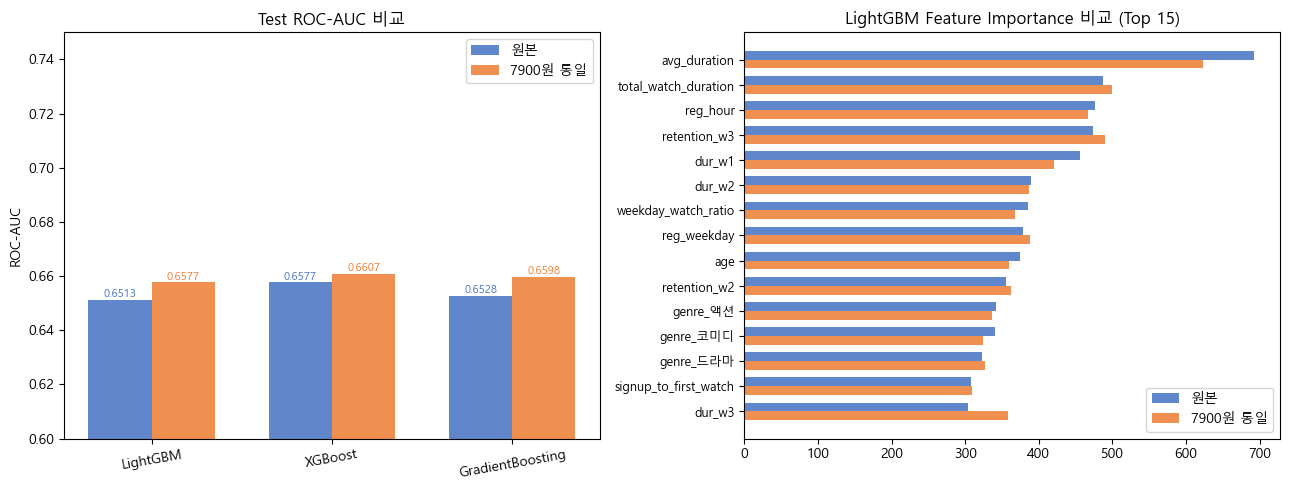

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_names = [r["name"] for r in results_orig]
auc_orig = [r["te"]["ROC-AUC"] for r in results_orig]
auc_7900v = [r["te"]["ROC-AUC"] for r in results_7900_list]
x = np.arange(len(model_names))
w = 0.35

axes[0].bar(x - w/2, auc_orig, w, label="원본", color="#4472C4", alpha=0.85)
axes[0].bar(x + w/2, auc_7900v, w, label="7900원 통일", color="#ED7D31", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=10)
axes[0].set_ylim(0.60, 0.75)
axes[0].set_title("Test ROC-AUC 비교")
axes[0].set_ylabel("ROC-AUC")
axes[0].legend()
for i, (o, n) in enumerate(zip(auc_orig, auc_7900v)):
    axes[0].text(i-w/2, o+0.001, "{:.4f}".format(o), ha="center", fontsize=8, color="#4472C4")
    axes[0].text(i+w/2, n+0.001, "{:.4f}".format(n), ha="center", fontsize=8, color="#ED7D31")

# LightGBM Feature Importance 비교
m_fi_o = results_orig[0]["model"]
m_fi_7 = results_7900_list[0]["model"]
fi_o = pd.Series(m_fi_o.feature_importances_, index=feat_cols).sort_values(ascending=False)
fi_7 = pd.Series(m_fi_7.feature_importances_, index=feat_cols).sort_values(ascending=False)

top_feats = fi_o.head(15).index.tolist()
fo_vals = [fi_o.get(f, 0) for f in top_feats]
f7_vals = [fi_7.get(f, 0) for f in top_feats]

y_pos = np.arange(len(top_feats))
axes[1].barh(y_pos - w/2, fo_vals, w, label="원본", color="#4472C4", alpha=0.85)
axes[1].barh(y_pos + w/2, f7_vals, w, label="7900원 통일", color="#ED7D31", alpha=0.85)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(top_feats, fontsize=9)
axes[1].set_title("LightGBM Feature Importance 비교 (Top 15)")
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()